# NOTEBOOK EDA

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import os
import re

from IPython.display import display, Markdown

import missingno as msno
import sys

from rapidfuzz import process, fuzz

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\JAIME\Documents\GitHub\TFM-Sesgos-en-el-sistema-judicial-de-EEUU-\00_Data\00_Processed\df_eda.csv")

In [3]:
def convert_to_datetime(df):
    date_regex = r'^(?:(?:\d{4}[-/]\d{1,2}[-/]\d{1,2})|(?:\d{1,2}[-/]\d{1,2}[-/]\d{2,4}))(?:[\sT]+(?:[01]?\d|2[0-3]):[0-5]\d(?::[0-5]\d)?)?$'

    for col in df.columns:
        if df[col].dtype.name == 'object':
            mask = df[col].dropna().str.match(date_regex)
            if mask.all():
                df[col] = pd.to_datetime(df[col], errors='coerce', infer_datetime_format=True)

    return df

In [4]:
def convert_categorical(df):
    age_order = ['less than 25', '25-45', '46-65', 'greater than 65']
    score_order = ['low', 'medium', 'high']
    charge_degree_order = ["misdemeanor", "felony"]


    df["age_cat"] = pd.Categorical(df["age_cat"], categories= age_order, ordered=True)
    df["score_text"] = pd.Categorical(df["score_text"], categories= score_order, ordered=True)
    df["c_charge_degree"] = pd.Categorical(df["c_charge_degree"], categories= charge_degree_order, ordered=True)


    return df

In [5]:
df.columns

Index(['sex', 'age', 'age_cat', 'decile_score', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'score_text', 'screening_date', 'two_year_recid',
       'priors_count', 'c_charge_degree', 'start', 'end', 'event', 'person_id',
       'agency_text', 'ethnic_code_text', 'maritalstatus', 'language'],
      dtype='object')

In [6]:
df["score_text"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [7]:
df = convert_to_datetime(df)

In [8]:
df = convert_categorical(df)

## Guión


### -Sacar gráficos
    - Estadísticos descriptivos de las variables
    - .corr de scores y demográficas
    - is_recid y is_v_recid con demográficas
    - cantidad de falsos positivos y falsos negativos + porcentaje de acierto del score
    - Tablas de contigencias de variables demográficas sobre is_recid y v_is_recid y score intervalos

In [21]:
# En bar plot (plotly), animation_frame para la barra interactuable
def eda(df):
    lista_variables_numericas = df.select_dtypes(include = "number").columns.tolist()
    lista_variables_numericas.remove("person_id")
    lista_variables_categoricas = df.select_dtypes(include = ["object", "category"]).columns.tolist()
    lista_variables_temporales = df.select_dtypes(include = "datetime").columns.tolist()
    
    display(Markdown("# Análisis univariable"))

    for col in lista_variables_categoricas:
    # Sacamos valores únicos y sus conteos
        counts = df[col].value_counts(dropna=False)
        
        if df[col].nunique() <= 3:
            # Preparamos labels con nombre + conteo
            labels = [f'{valor}\n{count}' for valor, count in zip(counts.index, counts.values)]
            
            # Dibujamos el pie chart
            plt.figure()
            plt.pie(
                counts.values,
                labels=labels,
                autopct='%1.1f%%'
            )
            
            plt.title(f'Distribución de {col}')
            plt.show()

        else:
            total = counts.sum()

            df_count = counts.reset_index()
            df_count.columns = [col, "frecuencia"]
            df_count["pct"] = df_count["frecuencia"] / total

            fig = px.bar(
                df_count,
                x=col,
                y='frecuencia',
                text= df_count.apply(
                lambda r: f"{r['pct']:.1%}",
                axis=1
            ),
            )

            fig.update_layout(
            title=f'Número de personas por {col}',
            yaxis_title='Número de personas'
            )

            fig.show()


    # df["ethnic_code_text"].value_counts().plot(kind="bar")
    # plt.title('Distribucion de personas por raza')
    # plt.show()

    
    print(f"Media:\n{df[lista_variables_numericas].mean()}")
    print("\n")
    print(f"Mediana:\n{df[lista_variables_numericas].median()}")
    print("\n")
    print(f"Mínimo:\n{df[lista_variables_numericas].min()}")
    print("\n")
    print(f"Máximo:\n{df[lista_variables_numericas].max()}")
    print("\n")
    print(f"Varianza:\n{df[lista_variables_numericas].var()}")
    print("\n")
    print(f"Desviación típica:\n{df[lista_variables_numericas].std()}")
    print("\n")
    print(f"Moda:\n{df[lista_variables_numericas].mode()}")

    for col in lista_variables_numericas:
        df[[col]].boxplot(figsize=(8,5))
        plt.title(f"Distribución general de {col}")
        plt.show()
        print("\n")

    display(Markdown("# Análisis bivariable"))
    print("\n")

    for col_num in lista_variables_numericas:
        for col_cat in lista_variables_categoricas:
            if col_cat != "sex":
                sns.boxplot(
                    data= df,
                    x=col_cat,
                    y= col_num,
                    hue="sex"
                )
                plt.title(f"Distribución de {col_num} por género y {col_cat}")
                plt.show()
                print("\n")

    # for col_num1 in lista_variables_numericas:
    #     for col_num2 in lista_variables_numericas:
    #         if col_num1 != col_num2:
    #             sns.relplot(
    #                 data= df,
    #                 x=col_num2,
    #                 y= col_num1,
                    
    #             )
    #             plt.title(f"Distribución de {col_num2} por {col_num1}")
    #             plt.show()
    #             print("\n")



    corr_matrix = df[lista_variables_numericas].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        center=0
    )

    plt.title("Matriz de correlación")
    plt.show()

    

 
    # for var in lista_variables_numericas:
    #     sns.lineplot(
    #         data=df,
    #         x="Año",
    #         y=var,
    #         hue="sex",
    #         marker="o"
    #     )
    #     plt.title(f"Evolución temporal de {var}")
    #     plt.xticks(df["Año"].unique())
    #     plt.show()
    #     print("\n")



In [10]:
# df = df.set_index("person_id")

# Análisis univariable

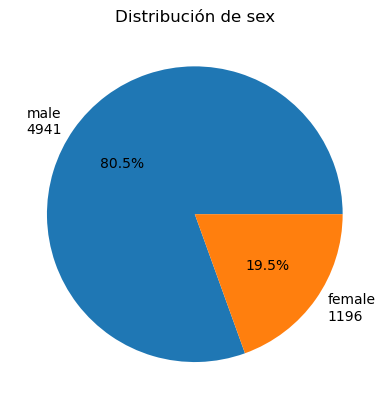

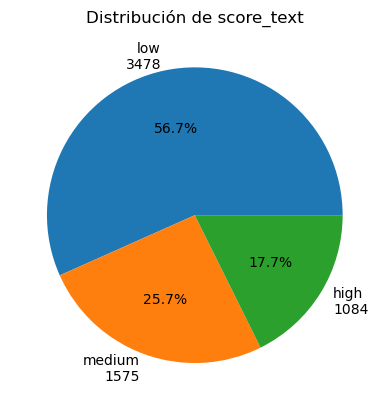

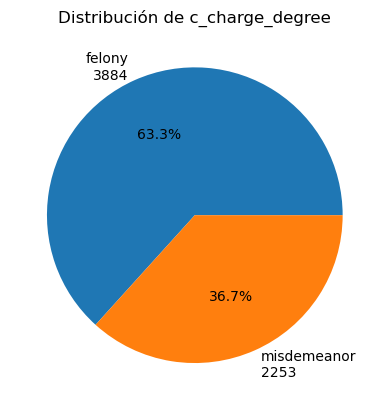

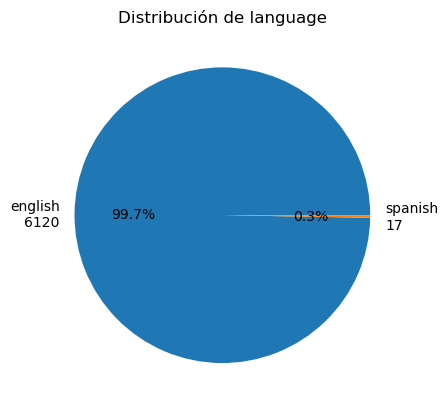

Media:
age                  35.281897
decile_score          4.334528
v_decile_score        3.587258
is_recid              0.397100
is_violent_recid      0.095812
two_year_recid        0.361577
priors_count          3.223399
start                11.876324
end                 612.888056
event                 0.314486
dtype: float64


Mediana:
age                  32.0
decile_score          4.0
v_decile_score        3.0
is_recid              0.0
is_violent_recid      0.0
two_year_recid        0.0
priors_count          1.0
start                 0.0
end                 750.0
event                 0.0
dtype: float64


Mínimo:
age                 19
decile_score         1
v_decile_score       1
is_recid             0
is_violent_recid     0
two_year_recid       0
priors_count         0
start                0
end                  1
event                0
dtype: int64


Máximo:
age                   96
decile_score          10
v_decile_score        10
is_recid               1
is_violent_recid   

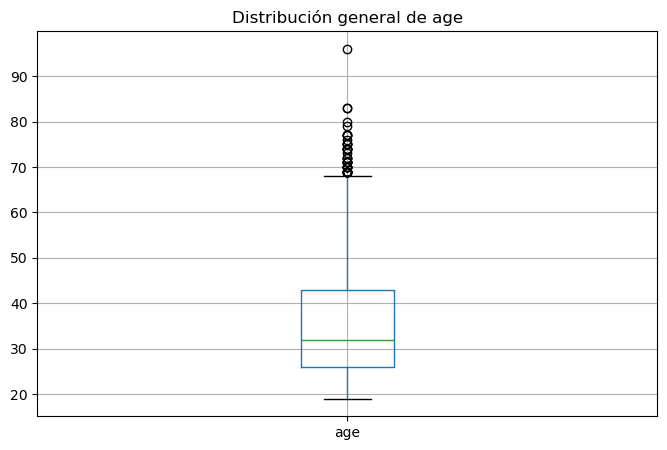

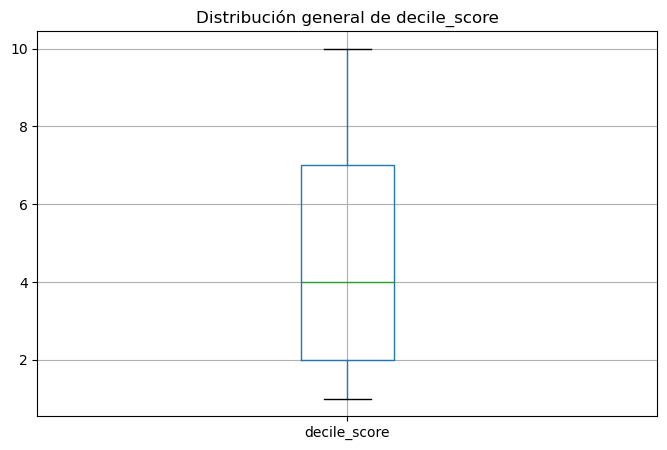

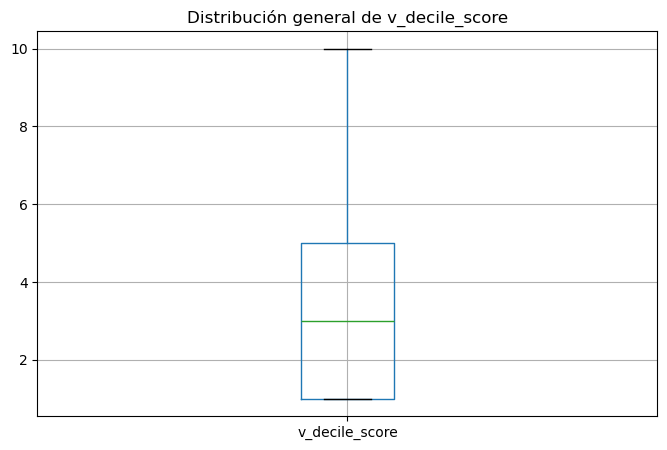

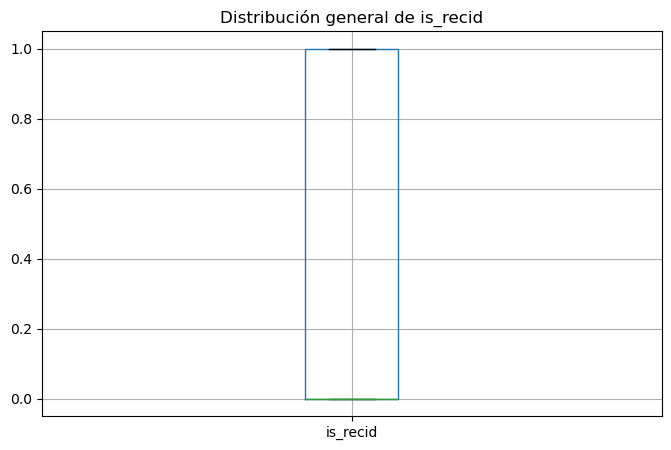

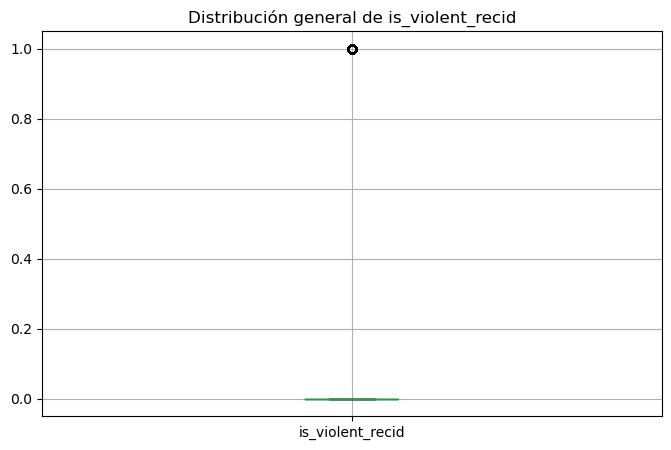

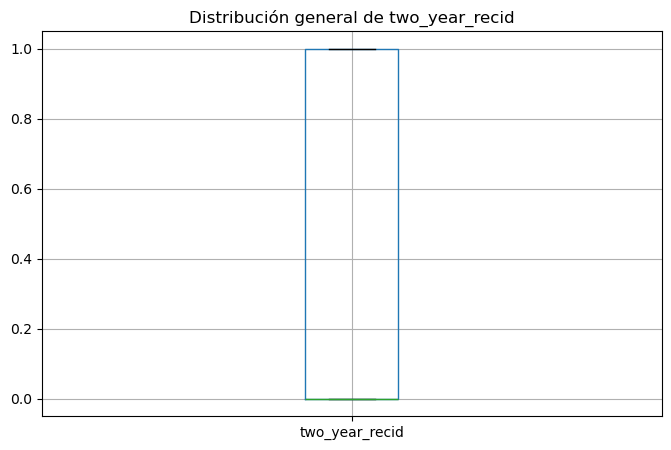

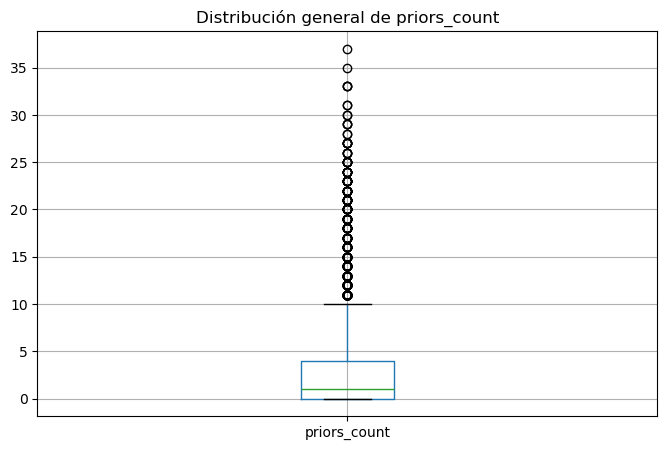

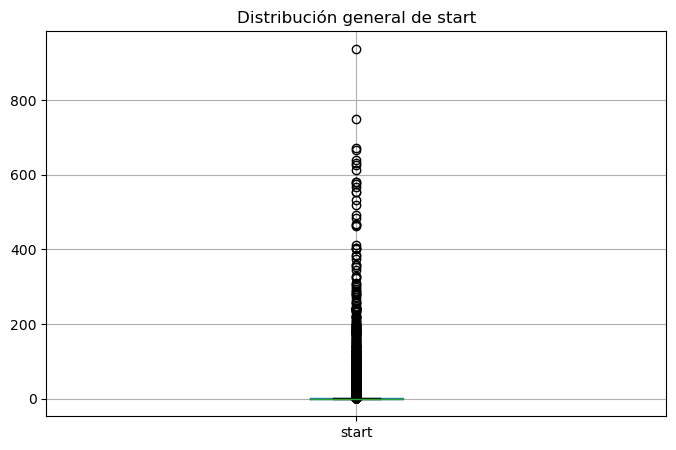

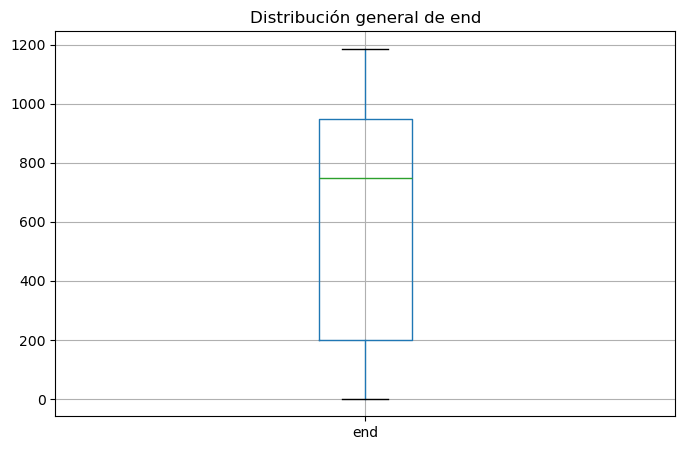

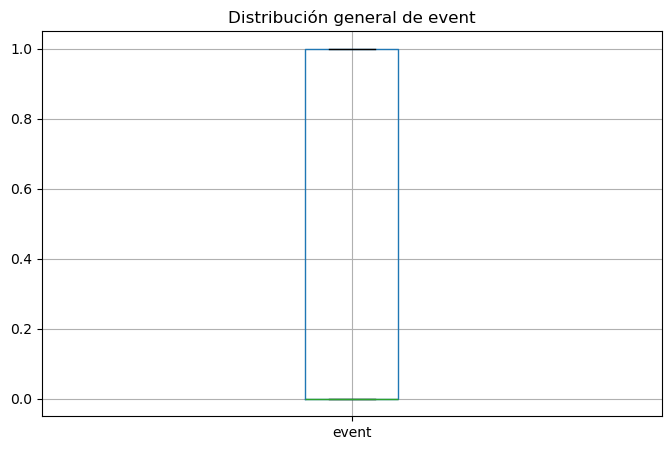

# Análisis bivariable

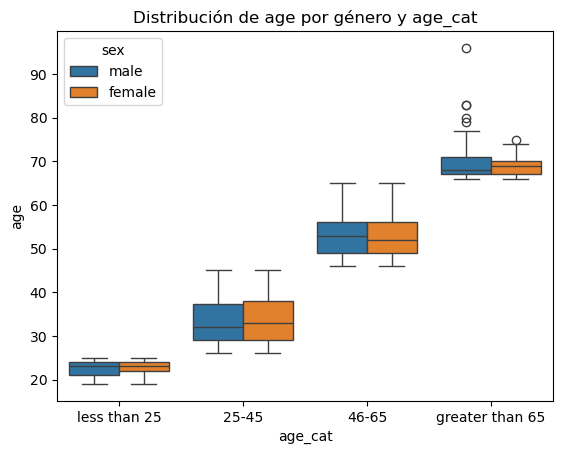

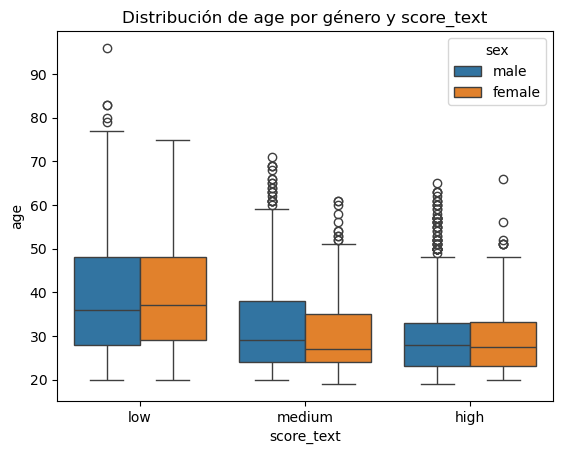

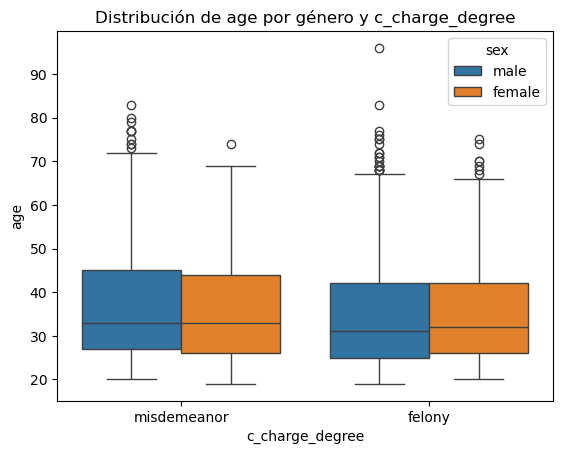

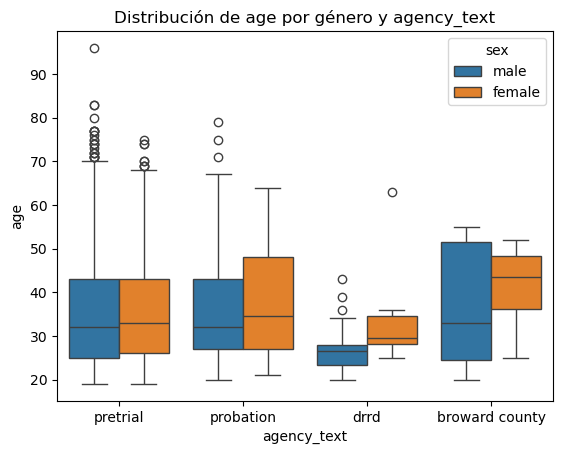

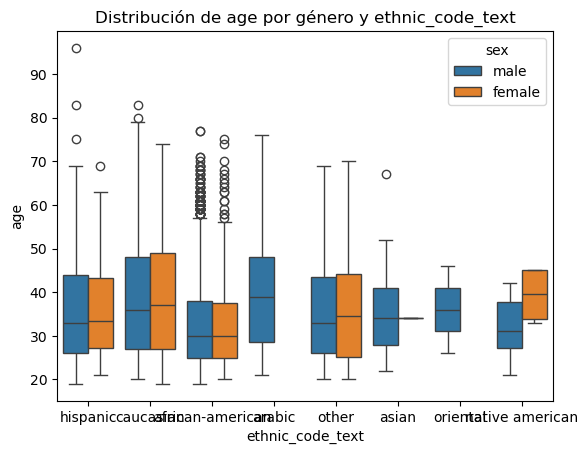

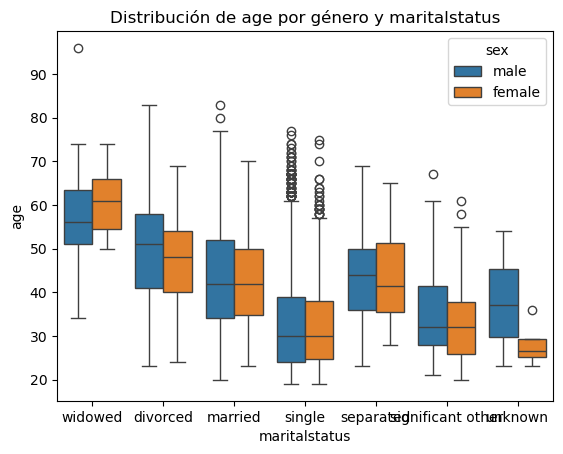

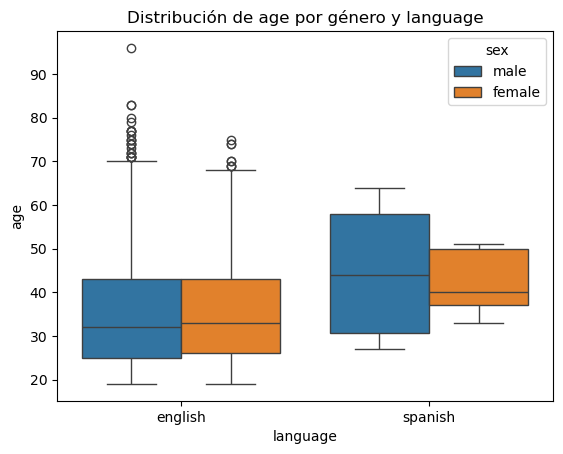

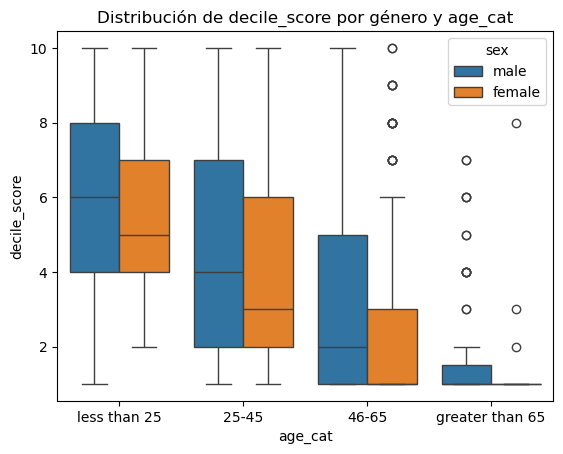

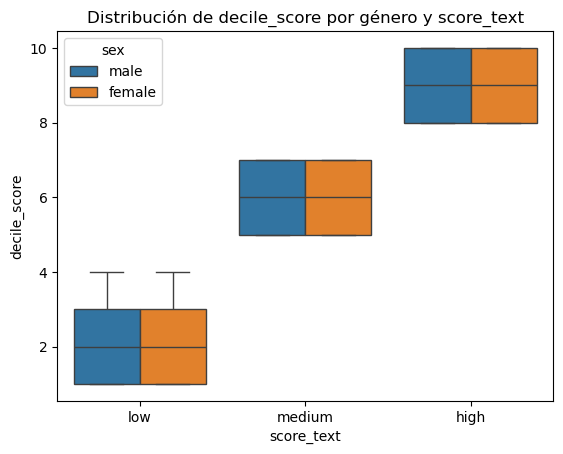

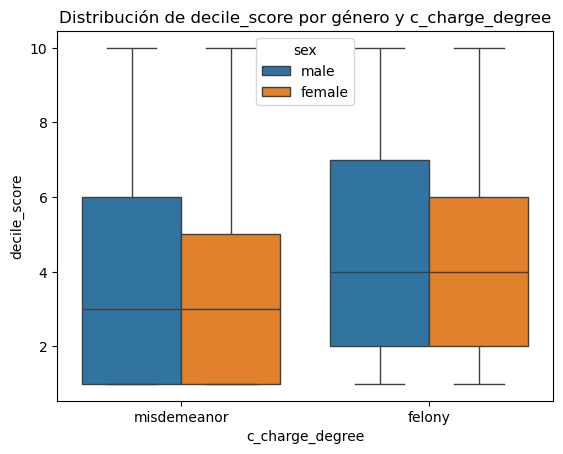

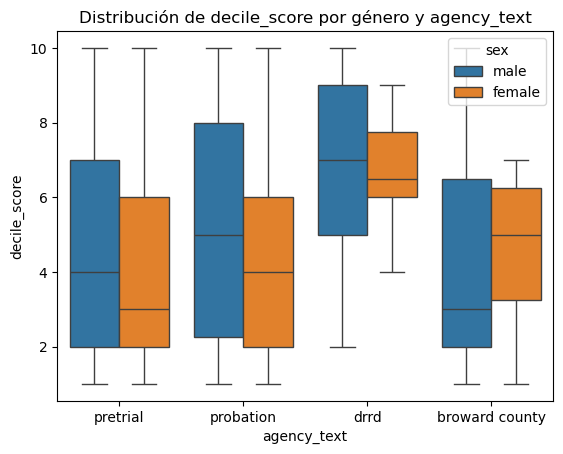

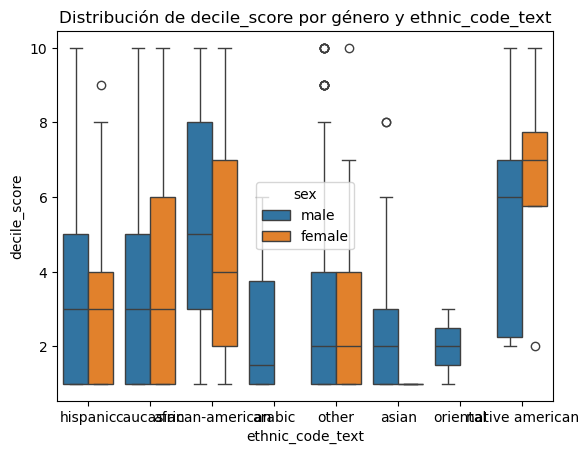

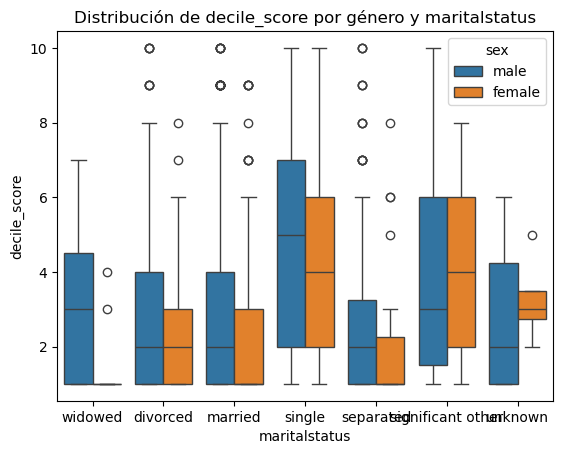

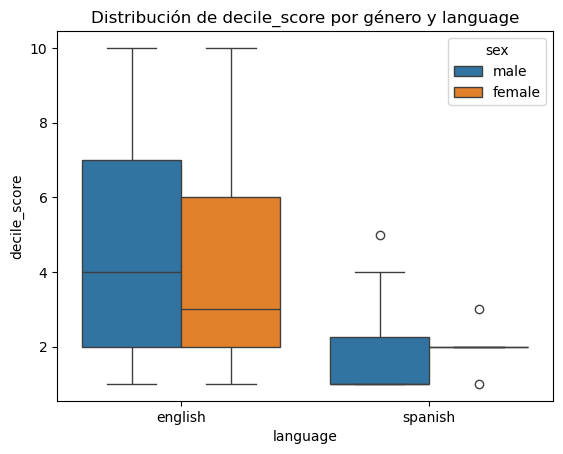

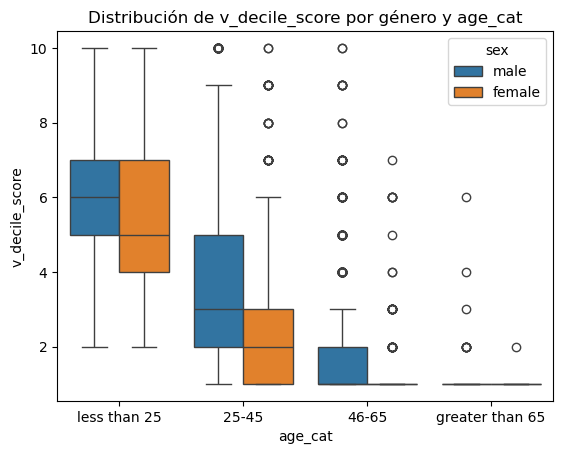

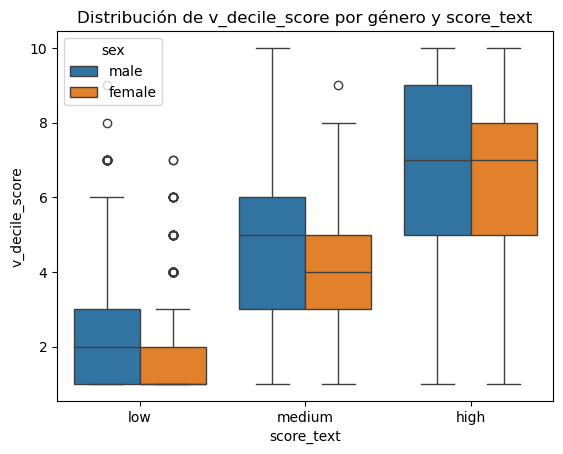

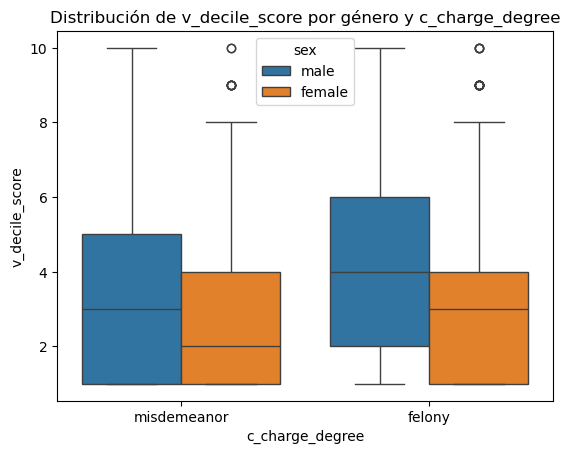

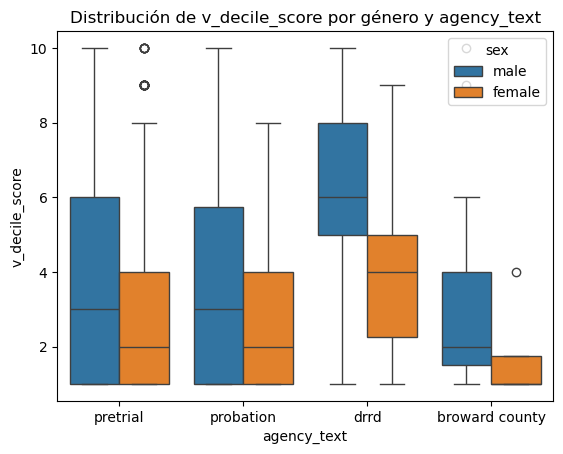

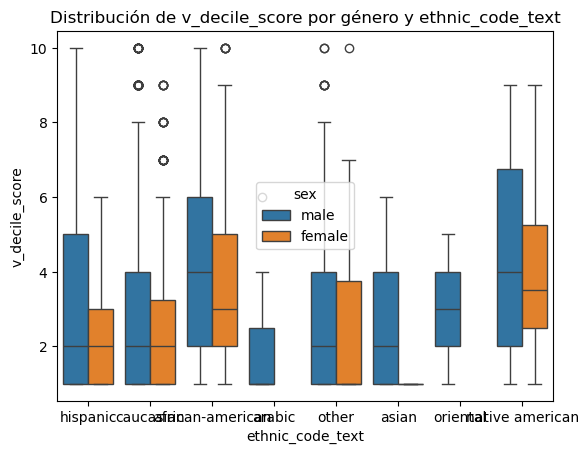

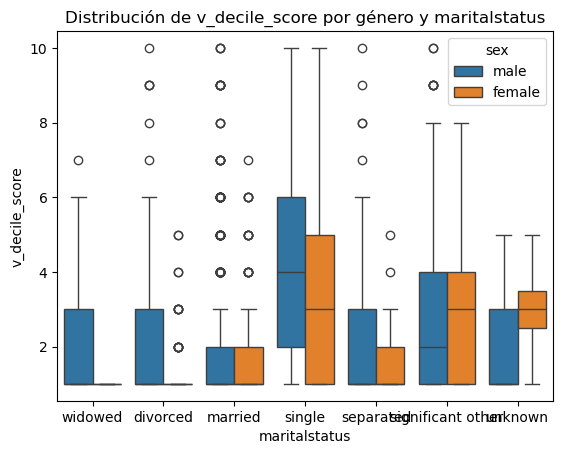

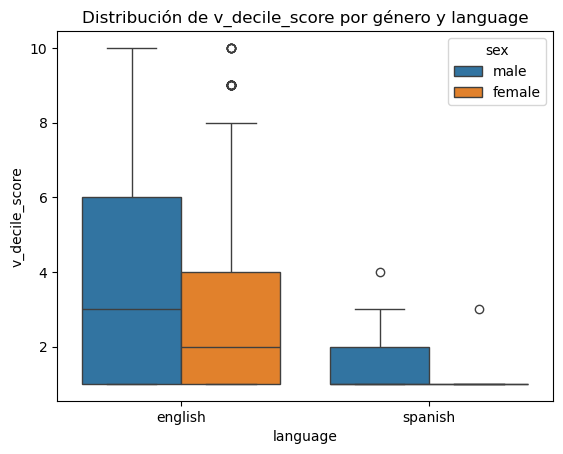

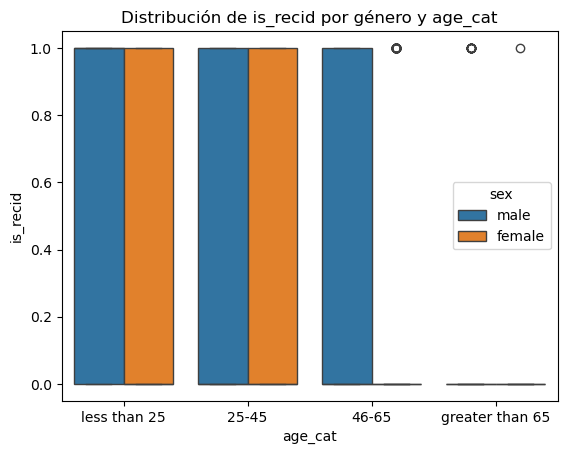

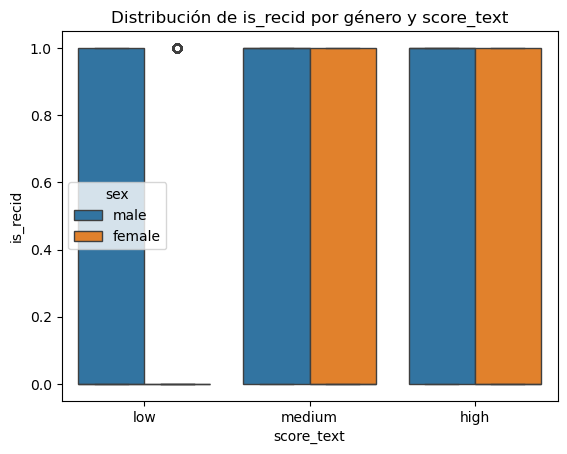

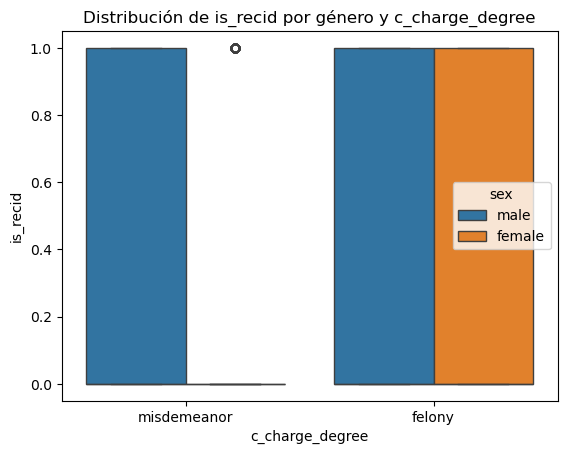

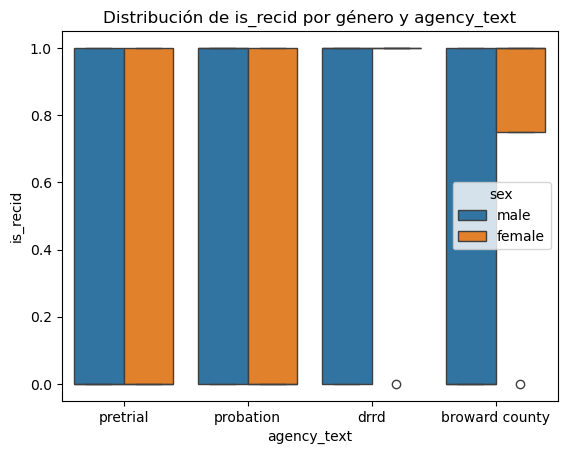

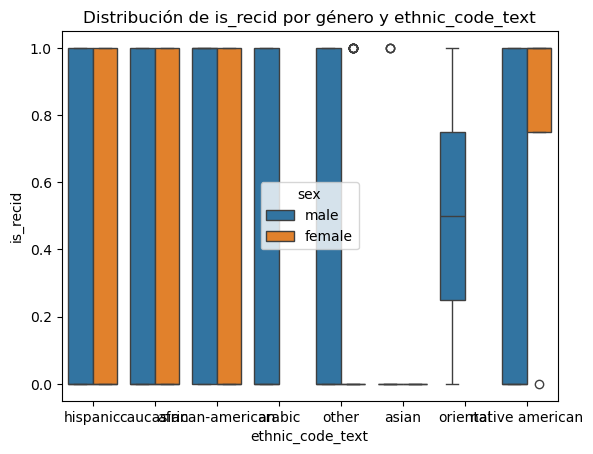

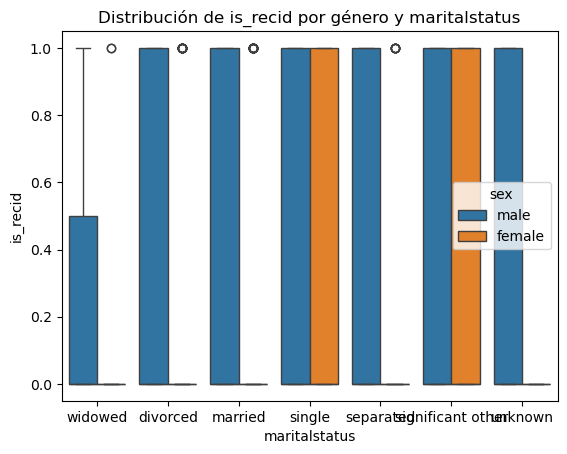

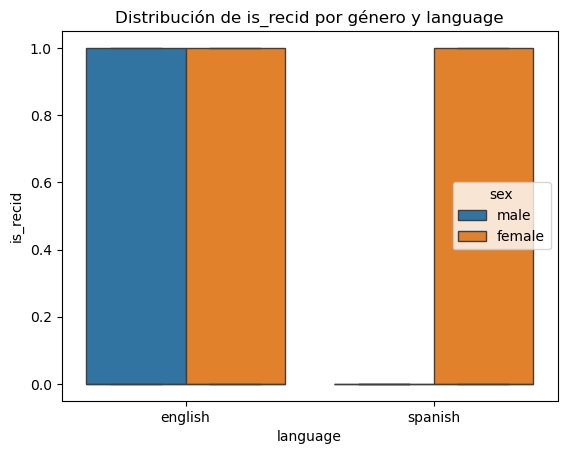

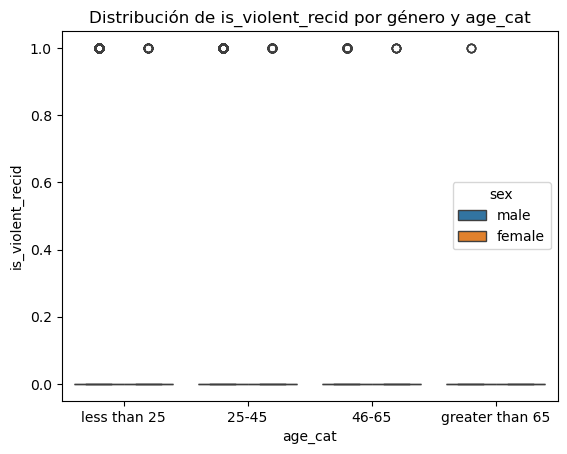

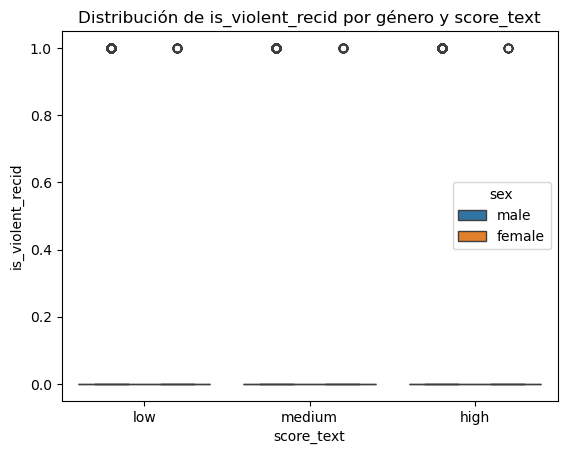

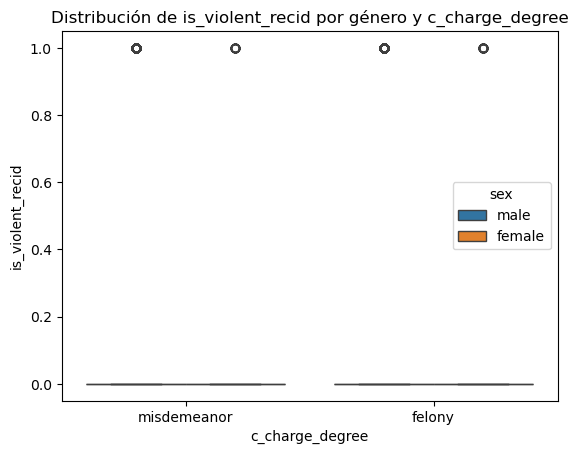

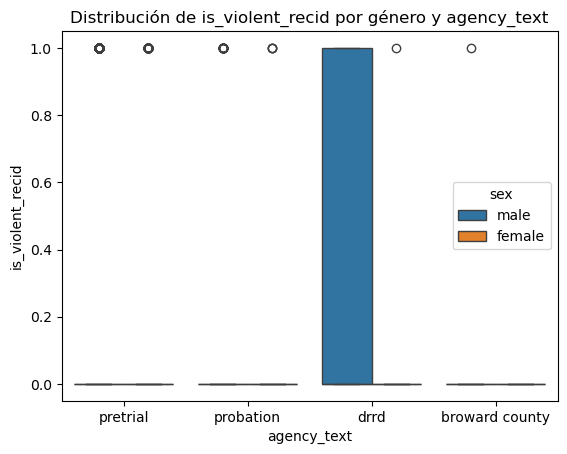

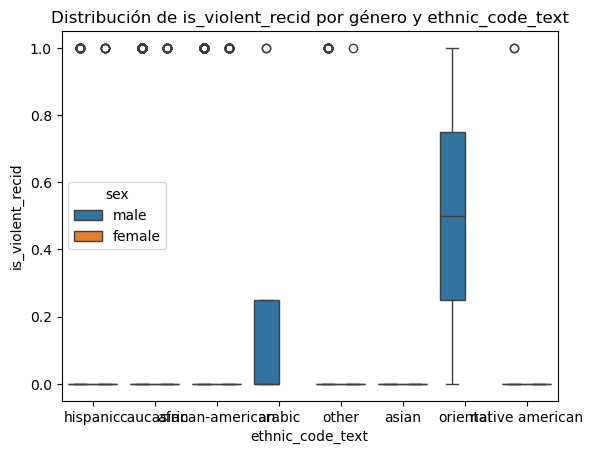

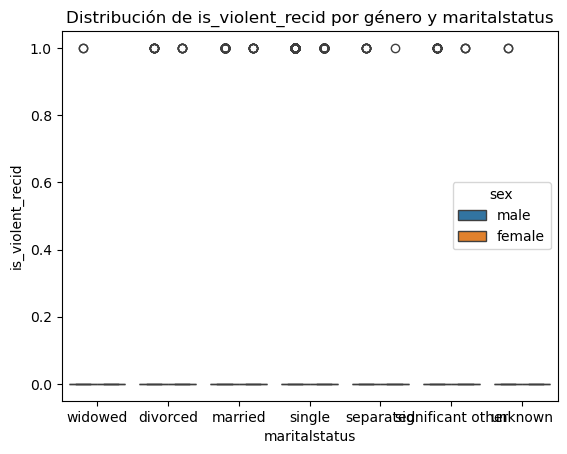

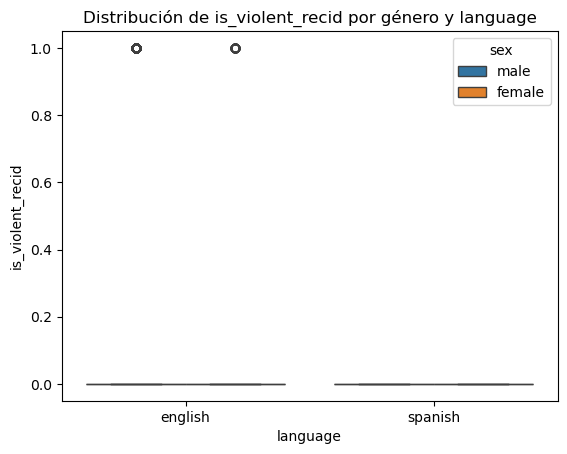

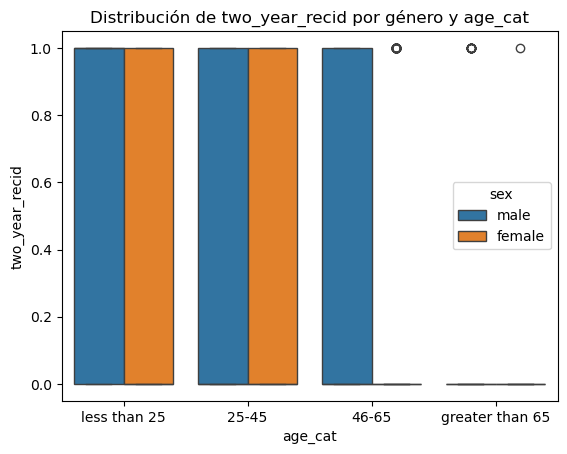

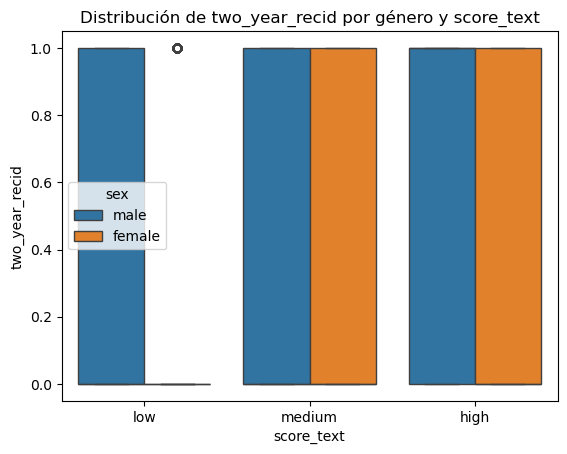

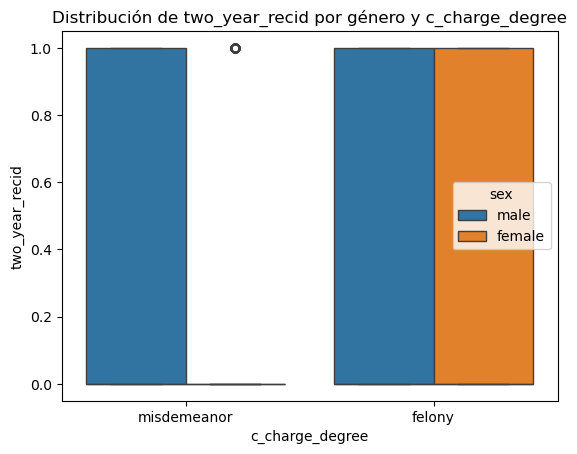

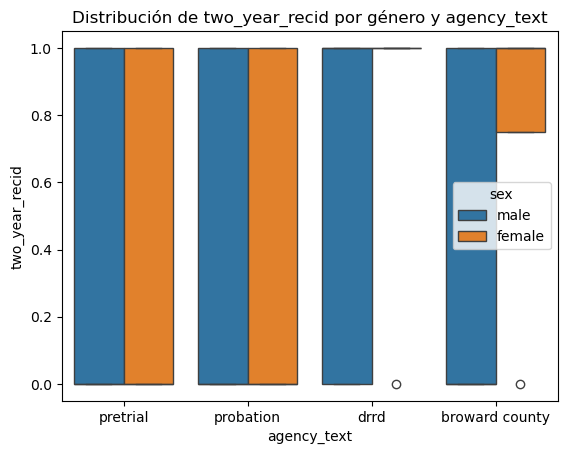

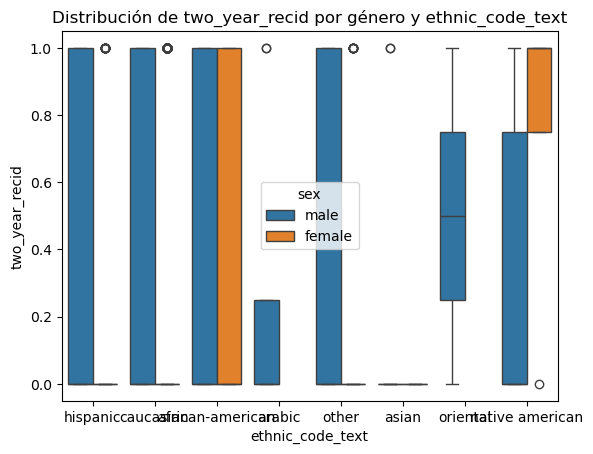

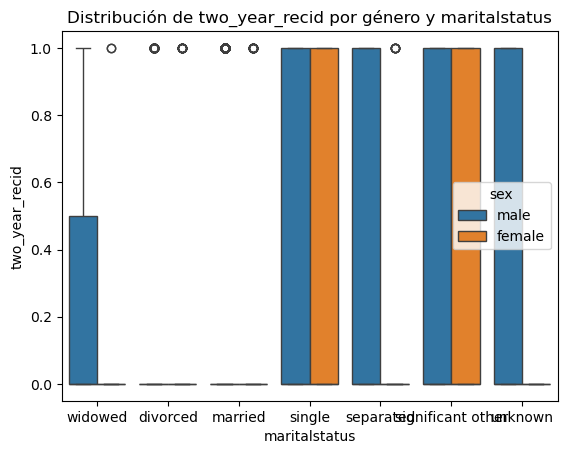

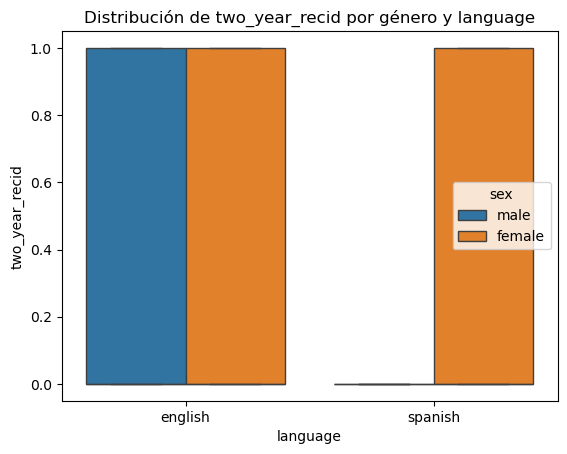

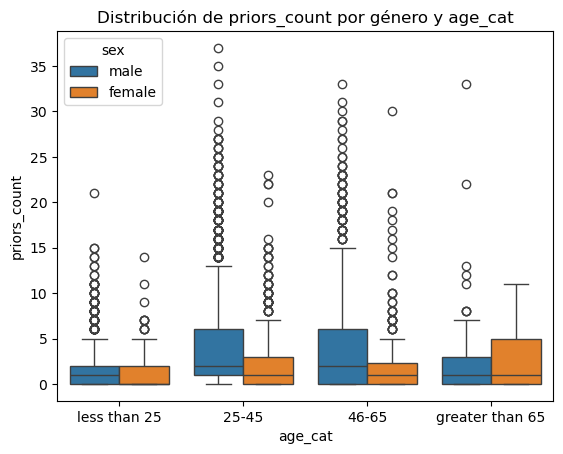

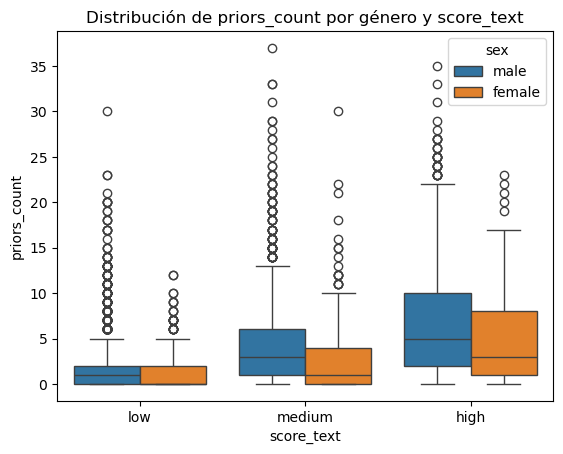

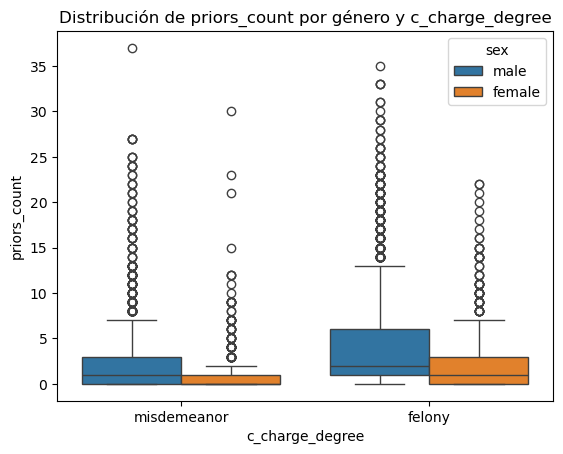

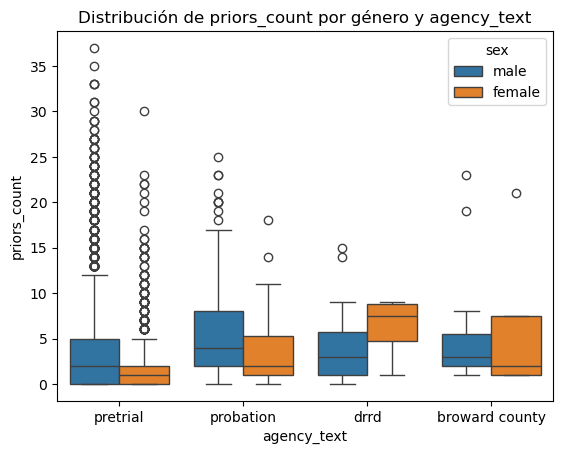

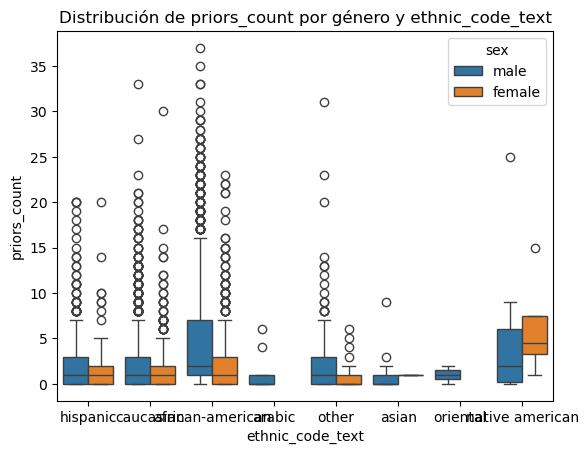

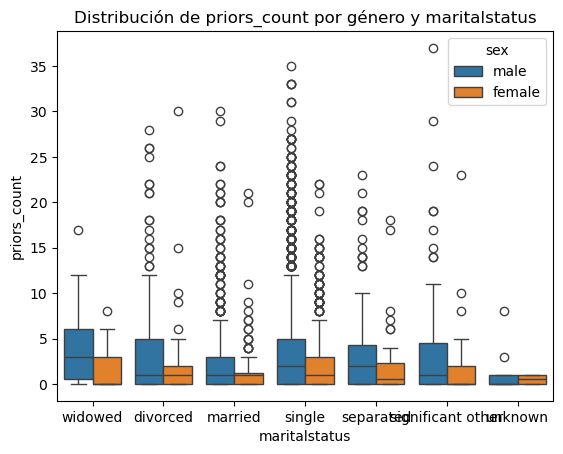

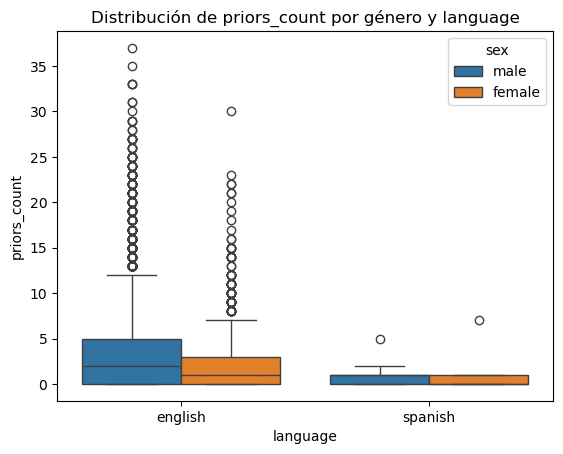

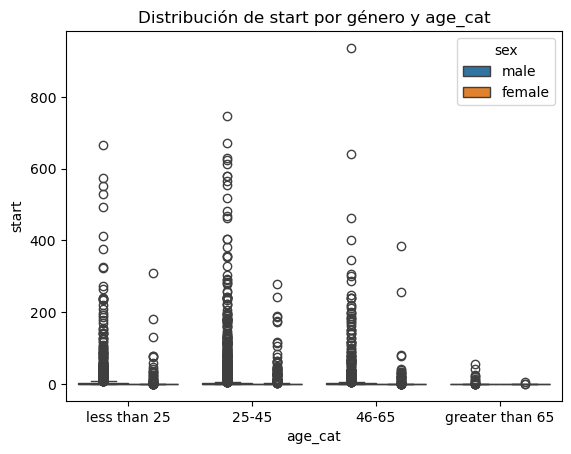

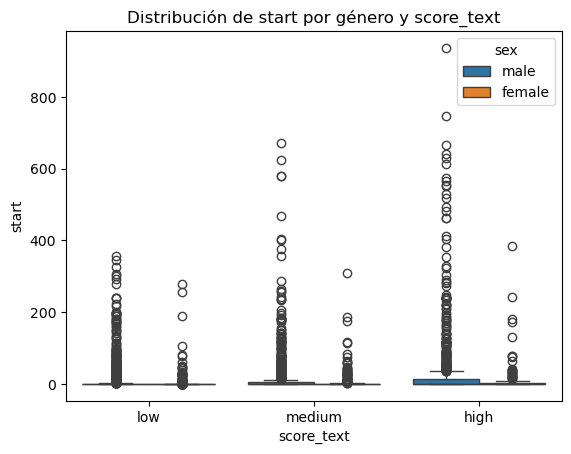

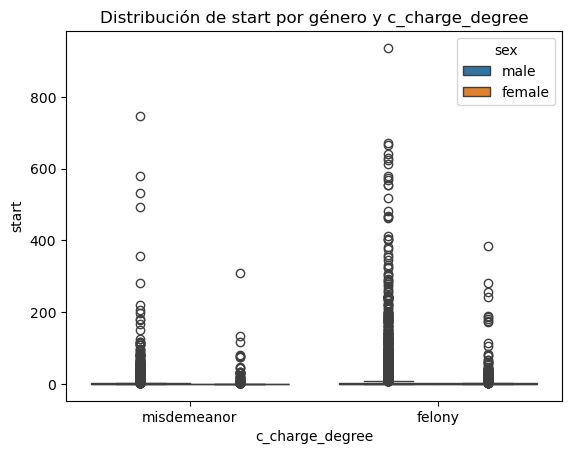

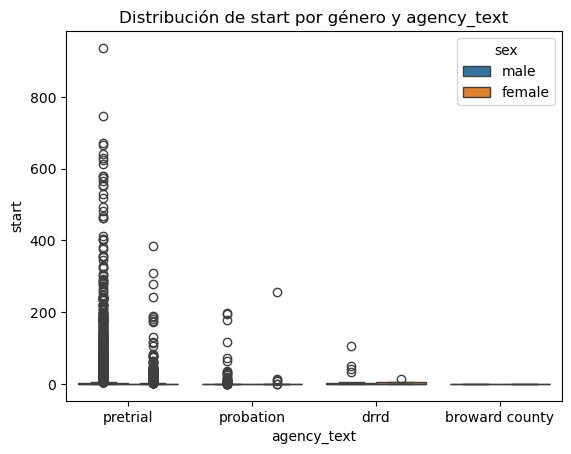

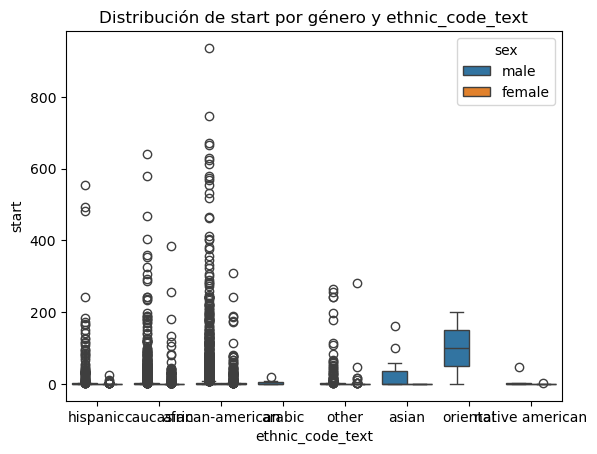

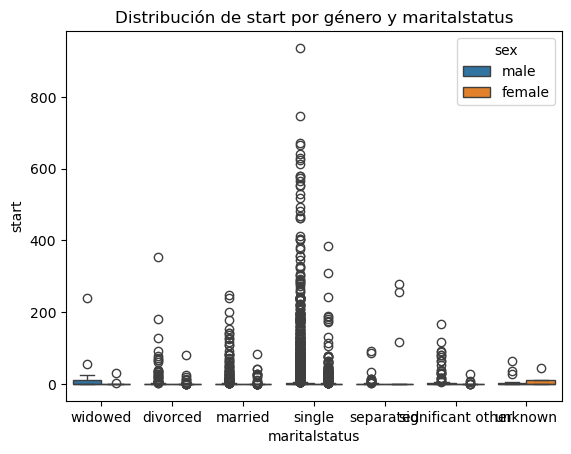

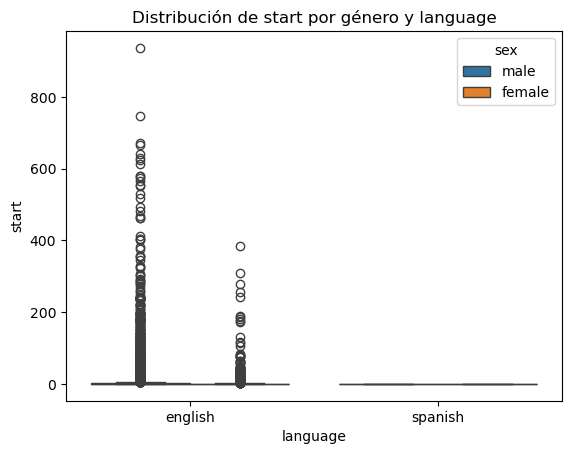

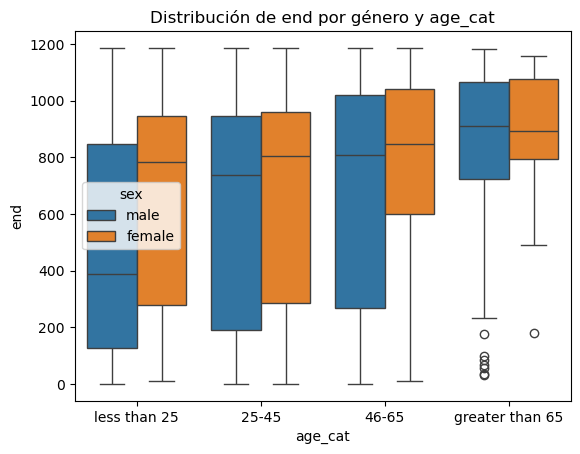

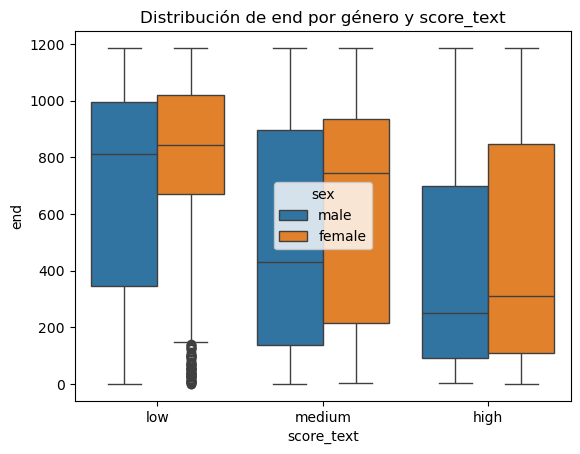

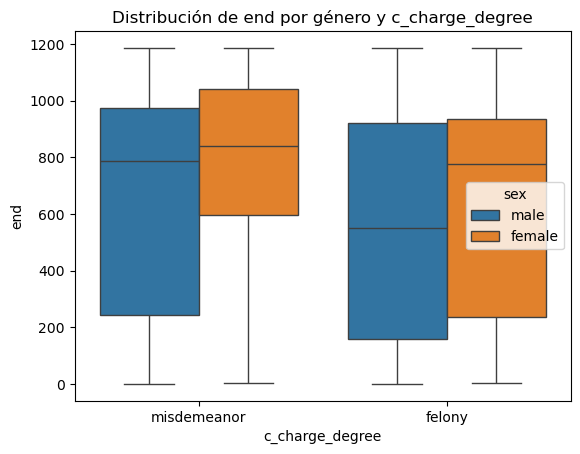

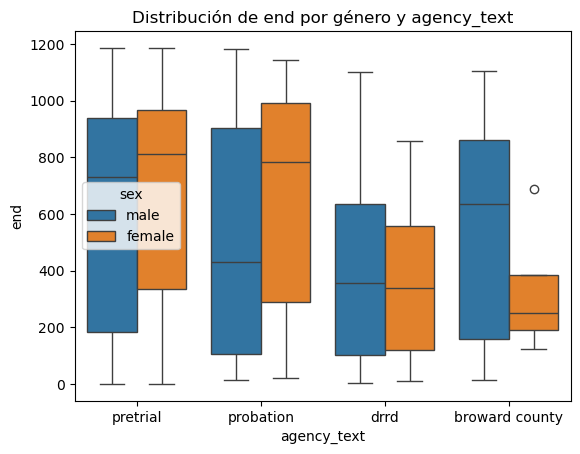

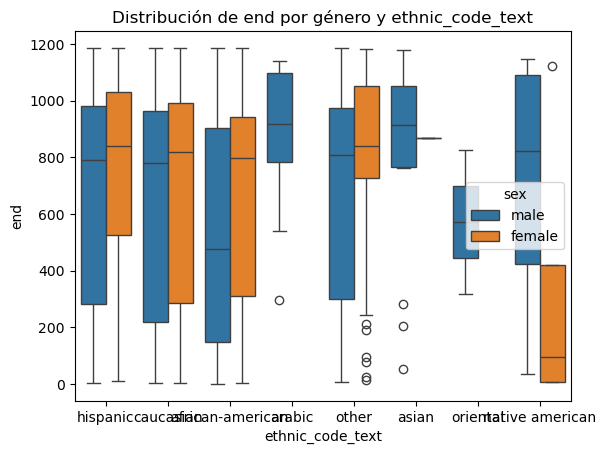

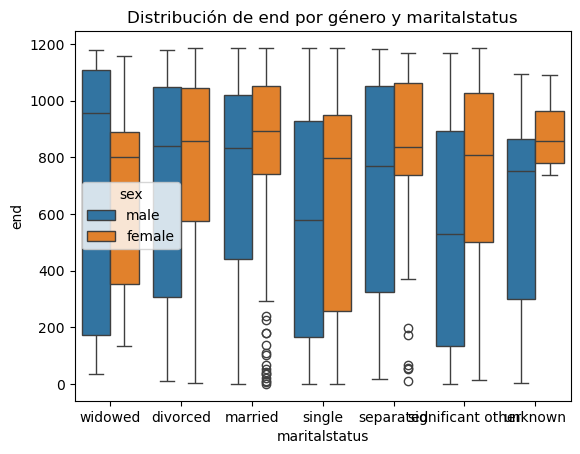

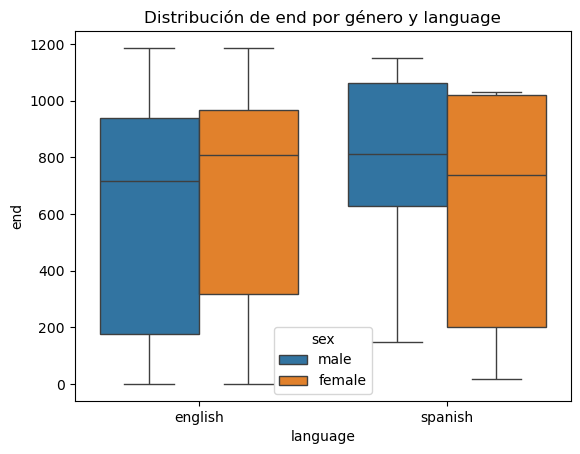

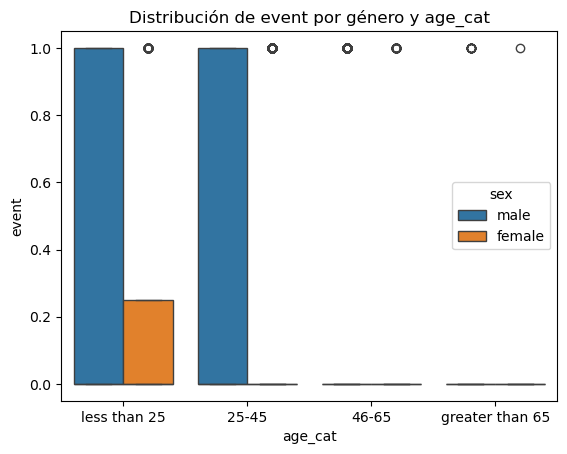

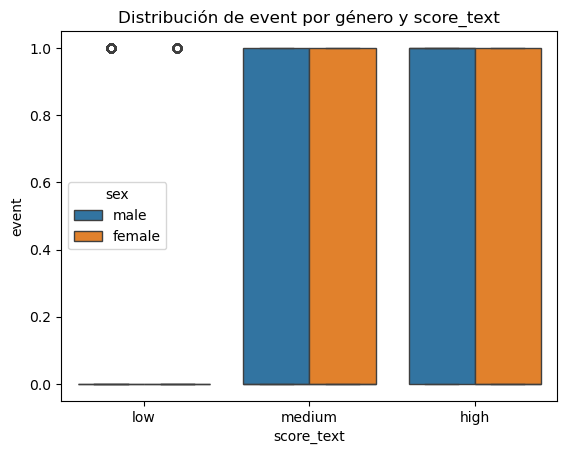

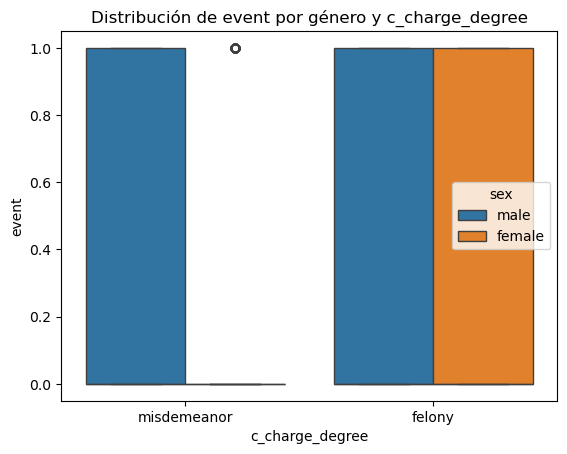

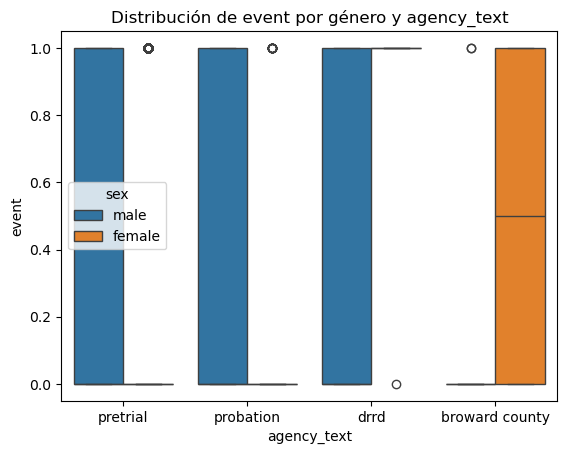

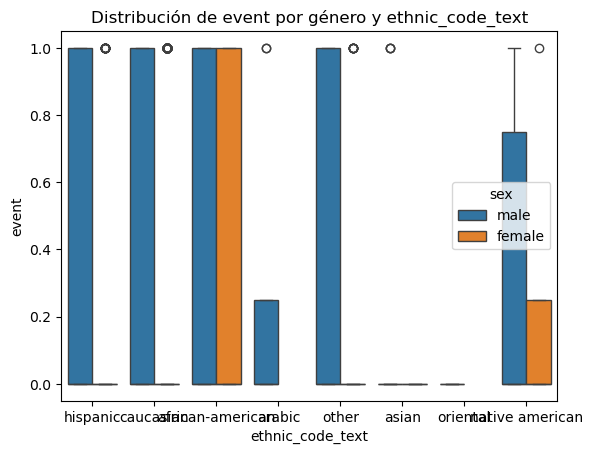

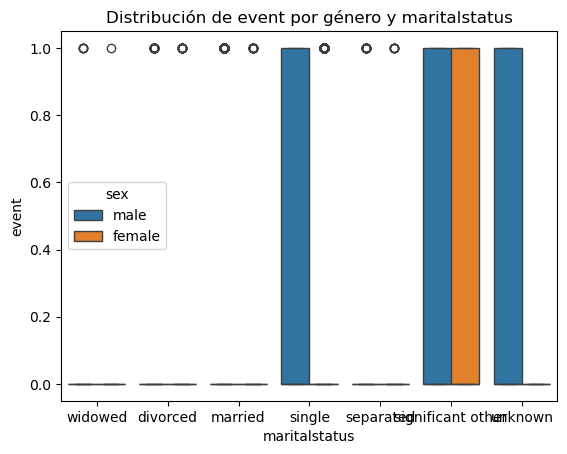

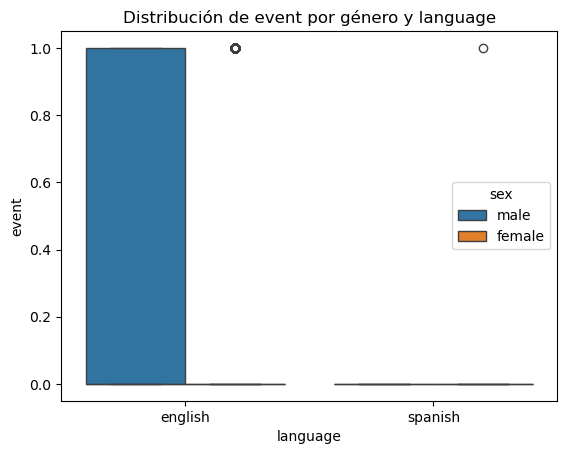

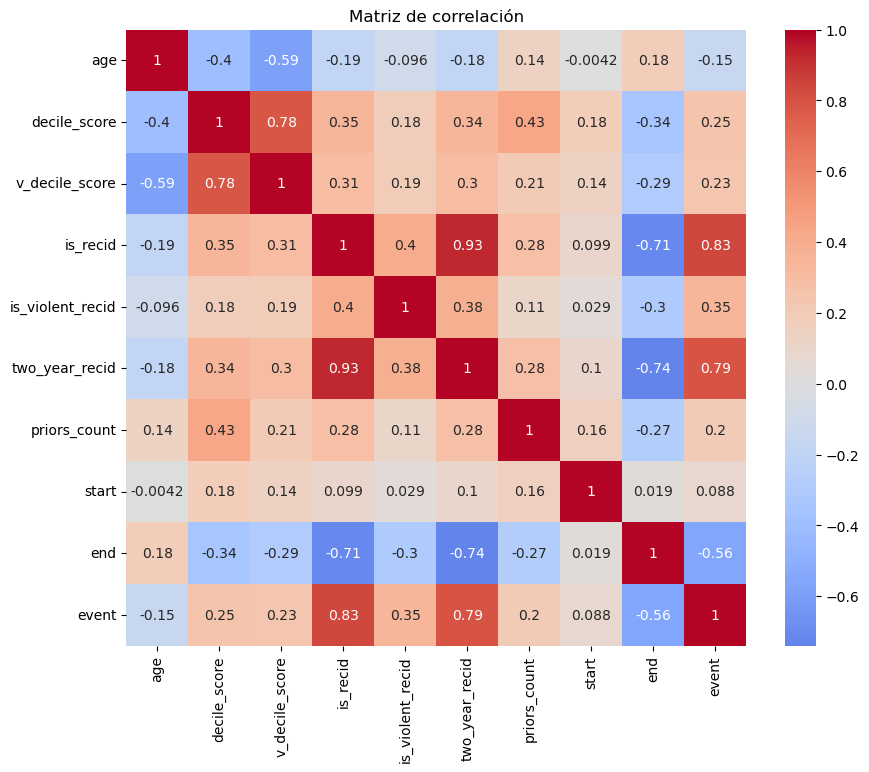

In [22]:
eda(df)

In [12]:
df["c_charge_degree"].unique()

['felony', 'misdemeanor']
Categories (2, object): ['misdemeanor' < 'felony']

In [13]:
df_count = (
        df['ethnic_code_text']
        .value_counts()
        .reset_index()
    )

In [14]:
df_count

,ethnic_code_text,count
0,african-american,3103
1,caucasian,2094
2,hispanic,565
3,other,333
4,asian,18
5,native american,14
6,arabic,8
7,oriental,2


In [15]:
df

,sex,age,age_cat,decile_score,v_decile_score,is_recid,is_violent_recid,score_text,screening_date,two_year_recid,priors_count,c_charge_degree,start,end,event,person_id,agency_text,ethnic_code_text,maritalstatus,language
0,male,96,greater than 65,2,1,1,0,low,2014-03-31,1,2,felony,0,178,1,62384.0,pretrial,hispanic,widowed,english
1,male,83,greater than 65,1,1,0,0,low,2013-08-08,0,4,felony,0,967,0,56279.0,pretrial,caucasian,divorced,english
2,male,83,greater than 65,1,1,0,0,low,2013-01-06,0,0,misdemeanor,1,1181,0,50959.0,pretrial,hispanic,married,english
3,male,80,greater than 65,1,1,0,0,low,2013-03-18,0,0,misdemeanor,0,1110,0,53038.0,pretrial,caucasian,married,english
4,male,79,greater than 65,1,1,0,0,low,2013-07-29,0,1,misdemeanor,0,977,0,56006.0,probation,caucasian,divorced,english
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6132,male,19,less than 25,9,9,1,0,high,2013-12-11,1,2,felony,0,71,1,59598.0,pretrial,african-american,single,english
6133,male,19,less than 25,10,10,1,0,high,2014-01-23,1,1,felony,0,711,1,60648.0,pretrial,african-american,single,english
6134,male,19,less than 25,10,9,1,1,high,2013-11-25,1,3,felony,0,412,1,59243.0,pretrial,african-american,single,english
6135,male,19,less than 25,10,10,1,1,high,2014-02-04,1,1,felony,0,64,0,60961.0,pretrial,african-american,single,english
